# Figures

Publication figures for the anti-diabetic peptide classifier in my dissertation.

Every figure is built from an exported CSV in `results/` or `screening/`, never by refitting a model.

Outputs go to `figures/` as a matched pair: PDF (vector, for reasearch proj) and PNG at 400 dpi (for slides or also reaserch proj).

In [1]:
# Shared style and save helper for every figure in this notebook.
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
BLUE, VERMILLION, GREY = "#0072B2", "#D55E00", "#999999"
ORANGE, GREEN = "#E69F00", "#009E73"   # completes the Okabe-Ito set for the four docking roles

# Okabe-Ito palette, safe under colour-vision deficiency and in greyscale print
BLUE, VERMILLION, GREY = "#0072B2", "#D55E00", "#999999"

plt.rcParams.update({
    "figure.dpi": 110, # on-screen preview only
    "savefig.dpi": 400, # raster export
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})


def save_figure(fig, name):
    """Write one figure to figures/ as both PDF and PNG."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    print(f"saved {name}.pdf and {name}.png")

## Figure 3

saved figure_3_model_comparison.pdf and figure_3_model_comparison.png


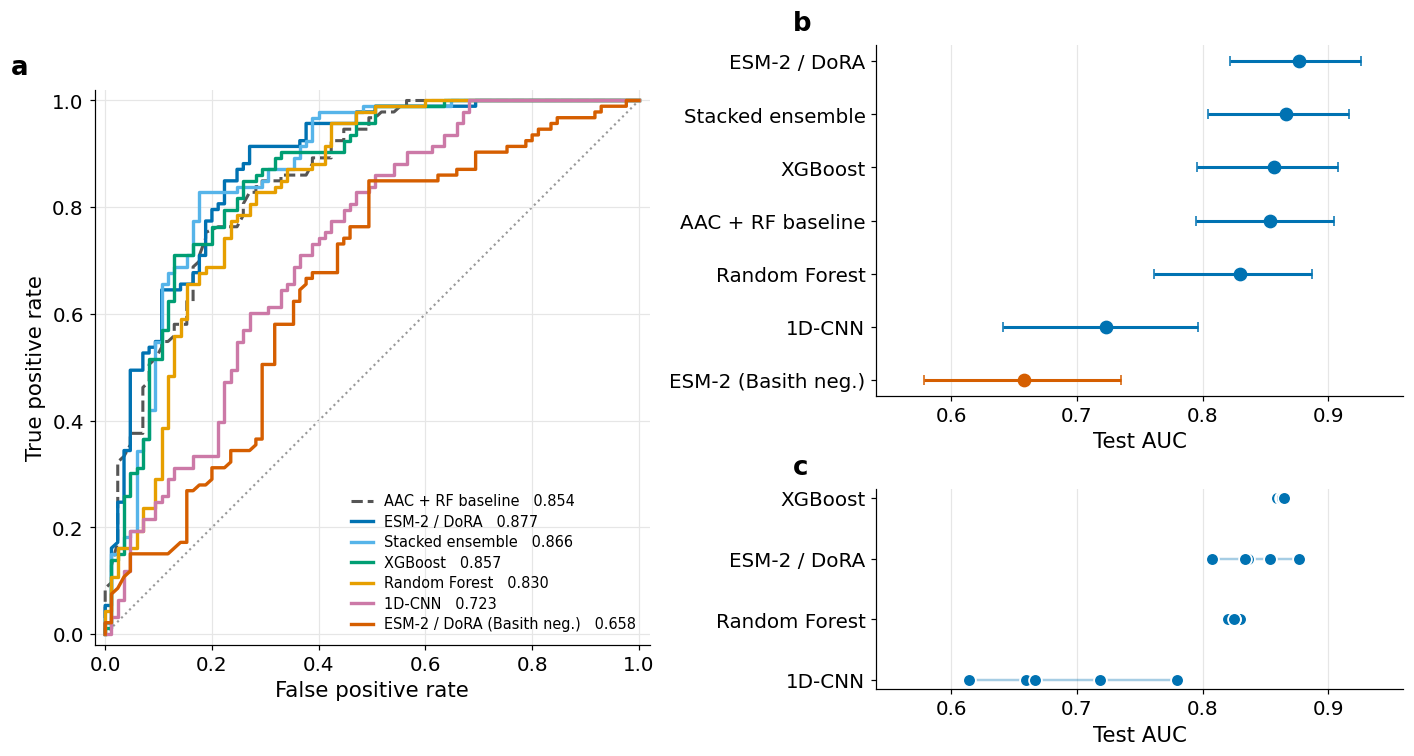

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

MODELS = [("ESM-2 / DoRA", "predictions/esm2_dora_predictions.npz", "esm_test", "#0072B2"),
          ("Stacked ensemble", "predictions/stack_predictions.npz", "stack_test", "#56B4E9"),
          ("XGBoost", "predictions/base_tree_predictions.npz", "xgb_test", "#009E73"),
          ("Random Forest", "predictions/base_tree_predictions.npz", "rf_test", "#E69F00"),
          ("1D-CNN", "predictions/base_cnn_predictions.npz", "cnn_test", "#CC79A7"),
          ("ESM-2 / DoRA (Basith neg.)",
           "predictions/esm2_dora_basith_predictions.npz", "esm_test", "#D55E00")]

y = np.load(MODELS[0][1], allow_pickle=True)["y_test"].astype(int)
curves = []
for name, path, key, colour in MODELS:
    d = np.load(path, allow_pickle=True)
    assert np.array_equal(d["y_test"].astype(int), y), f"{name} scored on a different test set"
    p = d[key].astype(float)
    curves.append((name, roc_auc_score(y, p), roc_curve(y, p), colour))
d = np.load("predictions/aac_baseline_predictions.npz", allow_pickle=True)
pb = d["aac_test"].astype(float)
bauc, (bfpr, btpr, _) = roc_auc_score(y, pb), roc_curve(y, pb)

ci = pd.read_csv("results/phase4_1_metrics_ci.csv")
ci = ci[~ci.model.str.contains("tuned")].sort_values("AUC").reset_index(drop=True)
SHORT = {"ESM-2 / DoRA (Basith negatives)": "ESM-2 (Basith neg.)",
         "AAC + RF (baseline)": "AAC + RF baseline"}
ci["short"] = ci.model.map(lambda m: SHORT.get(m, m))

st = pd.read_csv("results/phase4_2_seed_stability.csv")
st["label"] = st.model.map({"esm2": "ESM-2 / DoRA", "xgb": "XGBoost",
                            "rf": "Random Forest", "cnn": "1D-CNN"})
st = st.sort_values("mean_auc").reset_index(drop=True)

fig = plt.figure(figsize=(14.6, 7.6))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.95], height_ratios=[7, 4],
                      wspace=0.30, hspace=0.34)
ax = fig.add_subplot(gs[:, 0])          # ROC spans both rows
bx = fig.add_subplot(gs[0, 1])
cx = fig.add_subplot(gs[1, 1], sharex=bx)   # shared x makes b and c directly comparable

ax.plot([0, 1], [0, 1], ls=":", lw=1.4, color=GREY, zorder=1)
ax.plot(bfpr, btpr, ls="--", lw=2.0, color="#555555", zorder=2,
        label=f"AAC + RF baseline   {bauc:.3f}")
for name, auc, (fpr, tpr, _), colour in sorted(curves, key=lambda c: -c[1]):
    ax.plot(fpr, tpr, color=colour, lw=2.2, zorder=3, label=f"{name}   {auc:.3f}")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect("equal")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9.5, handlelength=1.5, labelspacing=0.38)

for i, r in ci.iterrows():
    colour = VERMILLION if "Basith" in r.model else BLUE
    bx.errorbar(r.AUC, i, xerr=[[r.AUC - r.AUC_lo], [r.AUC_hi - r.AUC]], fmt="o", ms=8,
                color=colour, ecolor=colour, elinewidth=2, capsize=3.5, zorder=3)
bx.set_yticks(range(len(ci)), ci.short)
bx.grid(axis="y", visible=False)
bx.set_xlabel("Test AUC")
bx.tick_params(labelbottom=True)

for i, r in st.iterrows():
    v = [float(x) for x in r.per_seed_auc.split(",")]
    cx.plot([min(v), max(v)], [i, i], color=BLUE, lw=1.6, alpha=0.35, zorder=2)
    cx.scatter(v, [i] * len(v), s=70, color=BLUE, edgecolor="white", linewidth=1.2, zorder=3)
cx.set_yticks(range(len(st)), st.label)
cx.grid(axis="y", visible=False)
cx.set_xlim(0.54, 0.96)
cx.set_xlabel("Test AUC")

# shift bx and cx right by 0.04 in figure coordinates
shift = 0.04
for a in (bx, cx):
    p = a.get_position()
    a.set_position([p.x0 + shift, p.y0, p.width, p.height])

for lab, a in zip("abc", (ax, bx, cx)):
    p = a.get_position()
    fig.text(p.x0 - 0.052, p.y1 + 0.018, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_3_model_comparison")
plt.show()

## Figure 4. Consensus reliability diagram

Sources `screening/consensus_calibration.csv`, the per-bin table written by Phase 5.0.

Point area is proportional to the number of out-of-fold peptides in each bin, so the eye weights
the bins the way the ECE weights them. The dotted line marks the 0.90 discovery threshold applied
in Phase 5.3. ECE is recomputed here from the per-bin table and cross-checked against the value
Phase 5.0 persisted, so a mismatch between the two files fails the cell rather than passing quietly.

saved figure_4_consensus_calibration.pdf and figure_4_consensus_calibration.png


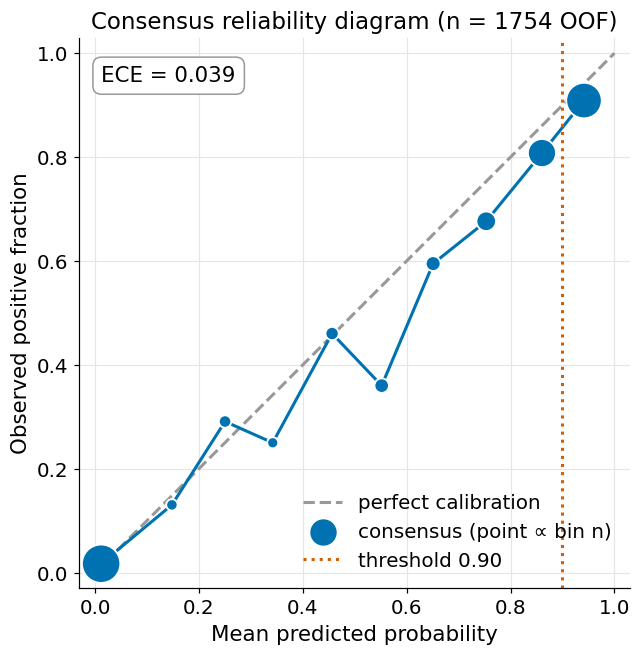

In [3]:
DISCOVERY_THRESHOLD = 0.90 # the cutoff applied in phase5.3, not the 0.87 the sweep permits

rel = pd.read_csv("screening/consensus_calibration.csv")

# ECE is the bin-count-weighted mean gap, recoverable from the exported table alone
ece = ((rel.n / rel.n.sum()) * (rel.mean_pred - rel.obs_pos).abs()).sum()
n_oof = int(rel.n.sum())

# cross-check against the value phase5.0 wrote
summary = pd.read_csv("results/phase5_0_calibration_summary.csv").set_index("quantity")["value"]
assert abs(ece - float(summary["ece_consensus_oof"])) < 5e-4, "ECE drift between table and summary"

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], ls="--", color=GREY, label="perfect calibration")
ax.plot(rel.mean_pred, rel.obs_pos, color=BLUE, zorder=2)
ax.scatter(rel.mean_pred, rel.obs_pos, s=1.2 * rel.n, color=BLUE, edgecolor="white",
           linewidth=1.2, zorder=3, label="consensus (point \u221d bin n)")
ax.axvline(DISCOVERY_THRESHOLD, color=VERMILLION, ls=":",
           label=f"threshold {DISCOVERY_THRESHOLD:.2f}")

ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.03)
ax.set_aspect("equal")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed positive fraction")
ax.set_title(f"Consensus reliability diagram (n = {n_oof} OOF)")
ax.annotate(f"ECE = {ece:.3f}", xy=(0.04, 0.92), xycoords="axes fraction", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=GREY))
ax.legend(loc="lower right")

save_figure(fig, "figure_4_consensus_calibration")
plt.show()

## Figure 5

saved figure_5_screening_funnel.pdf and figure_5_screening_funnel.png


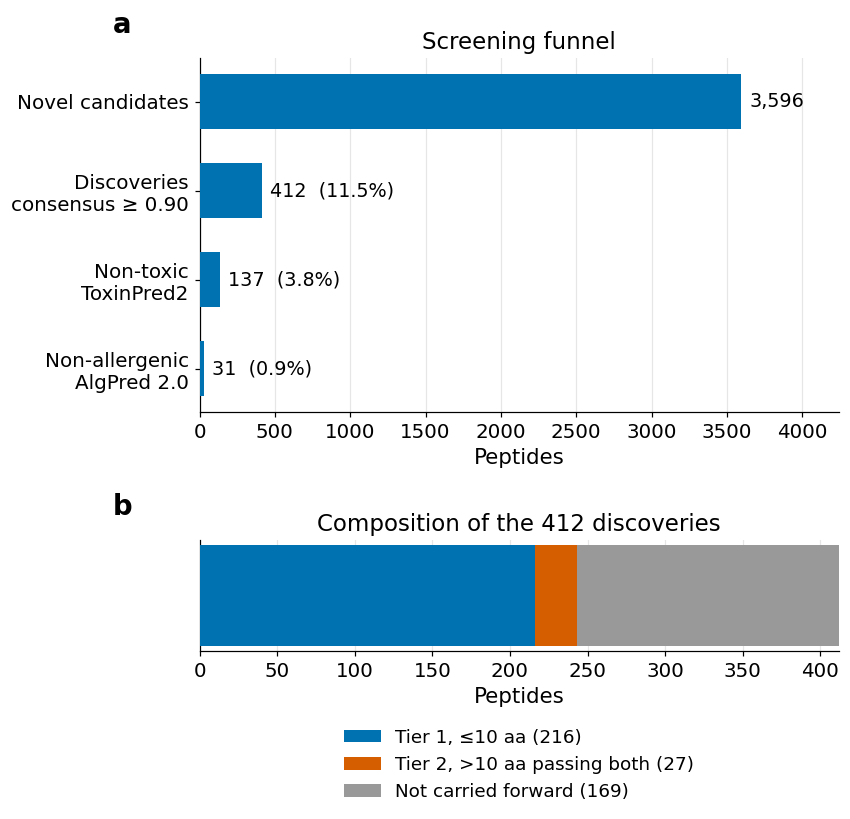

In [4]:
f = pd.read_csv("results/phase5_5_screening_funnel.csv").set_index("stage")["n"]

stages = [("Novel candidates", "novel_candidates"),
          ("Discoveries\nconsensus \u2265 0.90", "discoveries"),
          ("Non-toxic\nToxinPred2", "non_toxic"),
          ("Non-allergenic\nAlgPred 2.0", "non_toxic_non_allergen")]
labels, vals = [s[0] for s in stages], [int(f[s[1]]) for s in stages]

fig, (ax, bx) = plt.subplots(2, 1, figsize=(7.5, 7),
                             gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.55})

y = range(len(vals))
ax.barh(list(y), vals, color=BLUE, height=0.62, zorder=3)
ax.set_yticks(list(y), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(vals) * 1.18)
ax.set_xlabel("Peptides")
ax.set_title("Screening funnel")
ax.grid(axis="y", visible=False)
for i, v in zip(y, vals):
    pct = 100 * v / vals[0]
    ax.text(v + max(vals) * 0.015, i, f"{v:,}" + (f"  ({pct:.1f}%)" if i else ""),
            va="center", fontsize=12.5)

# the tiers re-partition the discoveries, they do not continue the funnel
t1, t2 = int(f["tier1"]), int(f["tier2"])
rest = int(f["discoveries"]) - t1 - t2
segs = [(f"Tier 1, \u226410 aa ({t1})", t1, BLUE),
        (f"Tier 2, >10 aa passing both ({t2})", t2, VERMILLION),
        (f"Not carried forward ({rest})", rest, GREY)]
left = 0
for lab, v, c in segs:
    bx.barh([0], [v], left=left, color=c, height=0.5, label=lab, zorder=3)
    left += v
bx.set_yticks([])
bx.set_xlim(0, int(f["discoveries"]))
bx.set_xlabel("Peptides")
bx.set_title(f"Composition of the {int(f['discoveries'])} discoveries")
bx.grid(axis="y", visible=False)
bx.legend(loc="upper center", bbox_to_anchor=(0.5, -0.55), fontsize=12)
# panel letters, referenced as Figure 5a and 5b in the text
for lab, a in zip("ab", (ax, bx)):
    fig.text(0.02, a.get_position().y1 + 0.025, lab, fontsize=18, fontweight="bold", va="bottom")

save_figure(fig, "figure_5_screening_funnel")
plt.show()

## Figure 6. Docking energetics of the net-charge artefact

Sources `results/phase5_5_docking.csv`, written by `phase5.5_docking_parse.py`.

Panel a ranks the eight docked peptides by how much of their favourable HADDOCK score comes from electrostatics, so the three cationic decoys separate from the leads and controls by sort order
alone. Panel b plots the two energies behind that split. Genuine binders sit left of the dashed line, burying surface favourably. the decoys sit right of it with large electrostatics, scoring
well without desolvating. Identity is carried by colour and marker shape together, never colour alone and both long Tier-2 sequences are labelled by candidate ID.

saved figure_6_docking_charge.pdf and figure_6_docking_charge.png


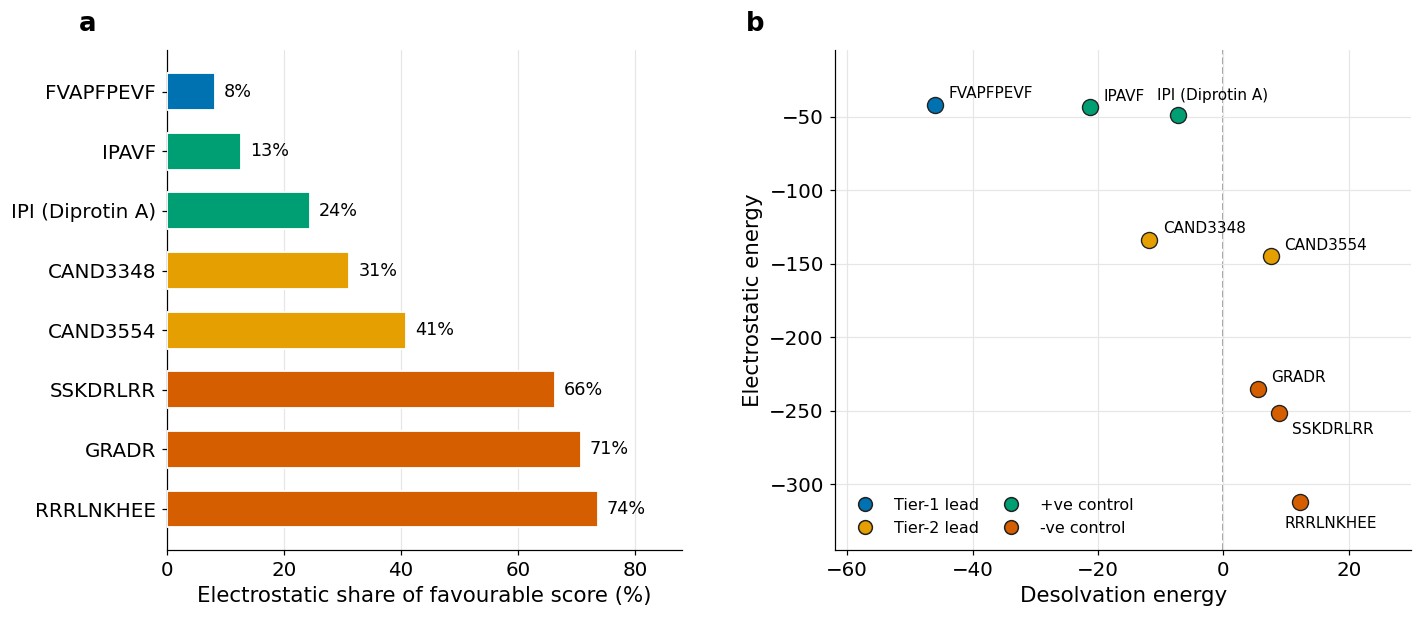

In [5]:
from matplotlib.lines import Line2D

COLOUR = {"Tier-1 lead": BLUE, "Tier-2 lead": ORANGE,
          "+ve control": GREEN, "-ve control": VERMILLION}
ORDER = ["Tier-1 lead", "Tier-2 lead", "+ve control", "-ve control"]

d = pd.read_csv("results/phase5_5_docking.csv")
man = pd.read_csv("docking/docking_manifest.csv")
nm = dict(zip(man.sequence, man.peptide_id.str.replace(r"^(LEAD_T\d_|POS_|NEG_)", "", regex=True)))
d["label"] = [s if len(s) <= 10 else nm.get(s, s[:8] + "\u2026") for s in d.peptide]
d.loc[d.peptide == "IPI", "label"] = "IPI (Diprotin A)"

fig, (ax, bx) = plt.subplots(1, 2, figsize=(14.6, 5.9),
                             gridspec_kw={"width_ratios": [1, 1.12], "wspace": 0.28})

# (a) share of the favourable score carried by charge, sorted so the decoys group at the bottom
s = d.sort_values("elec_pct_of_favourable")
y = range(len(s))
ax.barh(list(y), s.elec_pct_of_favourable, color=[COLOUR[r] for r in s.role],
        height=0.62, edgecolor="white", linewidth=1.2, zorder=3)
ax.set_yticks(list(y), s.label)
ax.invert_yaxis()
ax.set_xlim(0, 88)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Electrostatic share of favourable score (%)")
for i, v in zip(y, s.elec_pct_of_favourable):
    ax.text(v + 1.6, i, f"{v:.0f}%", va="center", fontsize=11.5)

# (b) the two energies behind the split. Offsets are per point, so no label overlaps a neighbour
bx.axvline(0, ls="--", lw=1.2, color=GREY, zorder=1)
OFFSET = {"FVAPFPEVF": (9, 4), "IPAVF": (9, 4), "IPI (Diprotin A)": (-14, 10),
          "CAND3348": (9, 4), "CAND3554": (9, 4),
          "GRADR": (9, 5), "SSKDRLRR": (9, -14), "RRRLNKHEE": (-10, -17)}
for r in d.itertuples():
    bx.scatter(r.desolv, r.elec, s=110, marker="o", c=COLOUR[r.role],
               edgecolors="#222222", linewidths=0.9, zorder=3)
    bx.annotate(r.label, (r.desolv, r.elec), xytext=OFFSET[r.label],
                textcoords="offset points", fontsize=10)
bx.set_xlabel("Desolvation energy")
bx.set_ylabel("Electrostatic energy")
bx.set_xlim(-62, 30)
bx.set_ylim(-345, -5)
bx.legend(handles=[Line2D([0], [0], marker="o", color="none", markerfacecolor=COLOUR[r],
                          markeredgecolor="#222222", markersize=9, label=r) for r in ORDER],
          loc="lower left", fontsize=10.5, ncol=2, columnspacing=1.0)

for lab, a in zip("ab", (ax, bx)):
    p = a.get_position()
    fig.text(p.x0 - 0.055, p.y1 + 0.03, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_6_docking_charge")
plt.show()

## Figure 8

saved figure_8_interpretability.pdf and figure_8_interpretability.png


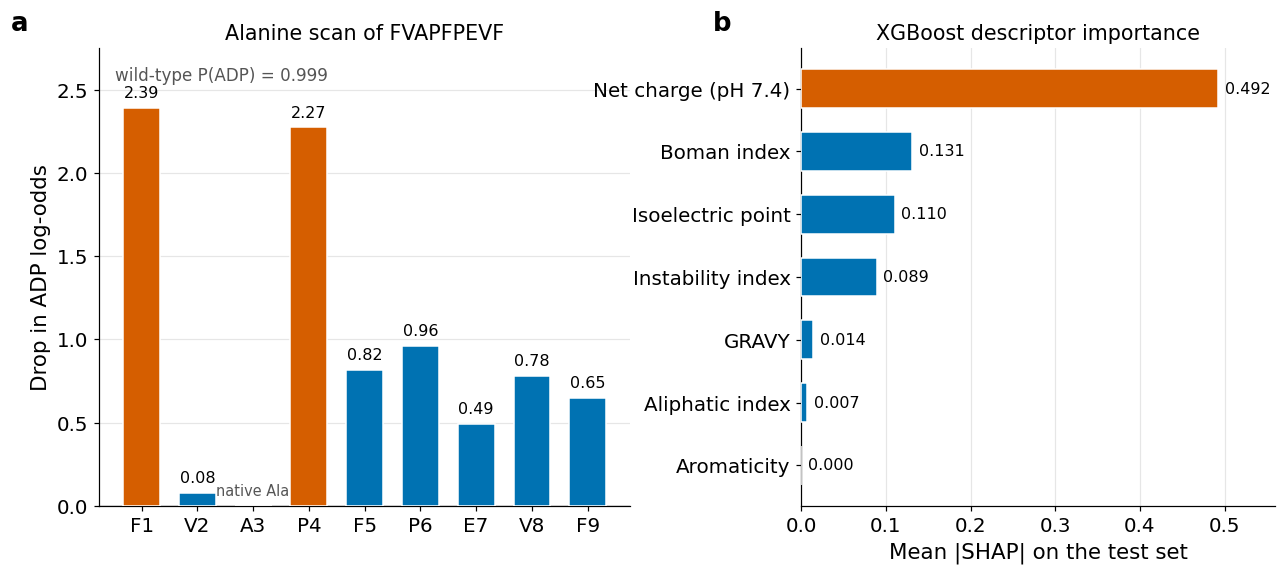

In [9]:
import math

PRETTY = {"net_charge_pH7.4": "Net charge (pH 7.4)", "boman_index": "Boman index",
          "isoelectric_point": "Isoelectric point", "instability_index": "Instability index",
          "gravy_kd": "GRAVY", "aliphatic_index": "Aliphatic index",
          "aromaticity": "Aromaticity"}

a = pd.read_csv("screening/alanine_FVAPFPEVF.csv")
wt = float(a.loc[a.already_ala, "P_mut"].iloc[0])   # A->A is a no-op, so this row is the wild type
s = pd.read_csv("screening/shap_descriptor_importance.csv")
s = s[s.model == "xgb"].copy()
s["label"] = s.feature.map(PRETTY)
s = s.sort_values("mean_abs_shap").reset_index(drop=True)

fig, (ax, bx) = plt.subplots(1, 2, figsize=(13.8, 5.4),
                             gridspec_kw={"width_ratios": [1.12, 1], "wspace": 0.34})

# (a) the two residues above 2.0 are highlighted, the native alanine greyed
labels = [f"{r.wt}{r.position}" for r in a.itertuples()]
colours = [GREY if r.already_ala else (VERMILLION if r.delta_logodds > 2 else BLUE)
           for r in a.itertuples()]
ax.bar(labels, a.delta_logodds, color=colours, width=0.66,
       edgecolor="white", linewidth=1.0, zorder=3)
ax.axhline(0, color="#222222", lw=0.8)
ax.set_ylim(0, 2.75)
ax.grid(axis="x", visible=False)
ax.set_ylabel("Drop in ADP log-odds")
ax.set_title("Alanine scan of FVAPFPEVF", fontsize=13.5)
for r in a.itertuples():
    if r.delta_logodds > 0.05:
        ax.text(r.position - 1, r.delta_logodds + 0.06, f"{r.delta_logodds:.2f}",
                ha="center", fontsize=10.5)
ax.annotate(f"wild-type P(ADP) = {wt:.3f}", xy=(0.03, 0.93), xycoords="axes fraction",
            fontsize=11, color="#555555")
ax.text(2, 0.06, "native Ala", ha="center", fontsize=9.5, color="#555555")

# (b) XGBoost only, since it is the learner in the consensus
y = range(len(s))
bx.barh(list(y), s.mean_abs_shap,
        color=[VERMILLION if v > 0.4 else BLUE for v in s.mean_abs_shap],
        height=0.62, edgecolor="white", linewidth=1.0, zorder=3)
bx.set_yticks(list(y), s.label)
bx.grid(axis="y", visible=False)
bx.set_xlim(0, 0.56)
bx.set_xlabel("Mean |SHAP| on the test set")
bx.set_title("XGBoost descriptor importance", fontsize=13.5)
for i, v in zip(y, s.mean_abs_shap):
    bx.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=10.5)

for lab, axis in zip("ab", (ax, bx)):
    p = axis.get_position()
    fig.text(p.x0 - 0.058, p.y1 + 0.03, lab, fontsize=17, fontweight="bold")

save_figure(fig, "figure_8_interpretability")
plt.show()

## Further figures

following the pattern above: read an exported CSV, build, call `save_figure`. Candidates still to move in here are the negative-set length distribution, the charge against length control from Phase 6.4, the FVAPFPEVF alanine scan and the SHAP descriptor importances.